# 🌬️ Borssele Offshore Wind Farm — Energy Generation Calculator

This notebook calculates how much electricity the **Borssele** offshore wind farms produce per year (Annual Energy Production, or **AEP**).

It uses:
- **Renewables.ninja** — a free website that gives us historical wind speed data at any location
- **Weibull distribution** — a statistical curve that describes how often different wind speeds occur
- **Power curves** — turbine manufacturer specs showing how much power a turbine makes at each wind speed

### Wind farms covered
| Farm | Turbine | Count | Rated Power |
|------|---------|-------|-------------|
| Borssele I & II | Siemens Gamesa SG 8.0-167 DD | 94 | 8.0 MW each |
| Borssele III | Vestas V164-9.5 MW | 77 | 9.5 MW each |
| Borssele IV | Vestas V164-9.5 MW | 2 | 9.5 MW each |

---
## Step 0 — Install & Import Libraries

Run this cell first. It loads everything the notebook needs.

In [1]:
# Install required libraries (only needed once)
# Uncomment and run the next line if you get an ImportError:
# !pip install requests pandas numpy scipy matplotlib

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
from scipy.special import gamma
import time

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
## Step 1 — Your Renewables.ninja API Token

Renewables.ninja requires a **free account** to access wind data via their API.

1. Go to https://www.renewables.ninja and click **Sign up** (it's free)
2. Once logged in, go to your **Profile** → copy your **API token**
3. Paste it below between the quotes

In [2]:
# 🔑 Paste your Renewables.ninja API token here:
API_TOKEN = "a5c8510f8f73c81cba039ec40f9fb4382e1ca8f1"

# The year of wind data to use (MERRA-2 data goes from 1980 to ~2023)
YEAR = 2022

print(f"Using wind data for year: {YEAR}")

Using wind data for year: 2022


---
## Step 2 — Define the Wind Farm Locations & Turbines

We define each wind farm's:
- GPS coordinates (latitude, longitude)
- Turbine type and hub height
- Number of turbines

In [3]:
# Wind farm definitions
# Each entry: name, latitude, longitude, number of turbines, turbine specs

wind_farms = [
    {
        "name": "Borssele I & II",
        "lat": 51.7028,        # 51°42'10"N
        "lon": 3.0761,         # 3°04'34"E
        "n_turbines": 94,
        "turbine_name": "Siemens Gamesa SG 8.0-167 DD",
        "rated_power_mw": 8.0,
        "hub_height_m": 120,
        "rotor_diameter_m": 167,
        "cutin_ws": 3.0,       # Wind speed where turbine starts generating [m/s]
        "rated_ws": 13.0,      # Wind speed where turbine reaches full power [m/s]
        "cutout_ws": 25.0,     # Wind speed where turbine shuts down (too windy) [m/s]
    },
    {
        "name": "Borssele III",
        "lat": 51.7400,        # 51°44'24"N
        "lon": 2.8797,         # 2°52'47"E
        "n_turbines": 77,
        "turbine_name": "Vestas V164-9.5 MW",
        "rated_power_mw": 9.5,
        "hub_height_m": 105,
        "rotor_diameter_m": 164,
        "cutin_ws": 4.0,
        "rated_ws": 13.5,
        "cutout_ws": 25.0,
    },
    {
        "name": "Borssele IV",
        "lat": 51.7228,        # 51°43'22"N
        "lon": 2.9297,         # 2°55'47"E
        "n_turbines": 2,
        "turbine_name": "Vestas V164-9.5 MW",
        "rated_power_mw": 9.5,
        "hub_height_m": 105,
        "rotor_diameter_m": 164,
        "cutin_ws": 4.0,
        "rated_ws": 13.5,
        "cutout_ws": 25.0,
    },
]

print("Wind farms defined:")
for wf in wind_farms:
    total_mw = wf['n_turbines'] * wf['rated_power_mw']
    print(f"  • {wf['name']}: {wf['n_turbines']} × {wf['rated_power_mw']} MW = {total_mw:.0f} MW total")

Wind farms defined:
  • Borssele I & II: 94 × 8.0 MW = 752 MW total
  • Borssele III: 77 × 9.5 MW = 732 MW total
  • Borssele IV: 2 × 9.5 MW = 19 MW total


---
## Step 3 — Download Wind Speed Data from Renewables.ninja

We ask Renewables.ninja for **hourly wind speeds** at each farm location.

The data comes from **NASA MERRA-2** — a global climate reanalysis dataset based on satellite and weather station observations.

> ⏳ This step downloads data from the internet. It may take 30–60 seconds per farm.

In [18]:
def fetch_wind_data(lat, lon, year, hub_height, token):
    """
    Download hourly wind speeds from Renewables.ninja for a given location and year.
    
    raw=1 returns wind speed at hub height instead of power output.
    """
    url = "https://www.renewables.ninja/api/data/wind"
    
    params = {
        "lat": lat,
        "lon": lon,
        "date_from": f"{year}-01-01",
        "date_to": f"{year}-12-31",
        "dataset": "merra2",
        "capacity": 1,             # Normalised (we use raw wind speed anyway)
        "height": hub_height,      # Wind speed at turbine hub height
        "turbine": "Vestas V80 2000",  # Placeholder (only matters when raw=0)
        "raw": True,                  # ← This gives us actual wind speeds in m/s
        "format": "json",
    }
    
    headers = {"Authorization": f"Token {token}"}
    
    response = requests.get(url, params=params, headers=headers)
    
    if response.status_code != 200:
        raise ValueError(f"API error {response.status_code}: {response.text[:200]}")
    
    data = response.json()
    
    df = pd.DataFrame.from_dict(data["data"], orient="index")
    df.index = pd.to_datetime(df.index.astype(int), unit="ms")
    df = df[["wind_speed"]].rename(columns={"wind_speed": "wind_speed_ms"})

    return df


# Download data for each farm
print(f"Downloading wind data for {YEAR}...\n")

all_wind_data = {}

for wf in wind_farms:
    print(f"  Fetching {wf['name']}...", end=" ")
    
    df = fetch_wind_data(
        lat=wf["lat"],
        lon=wf["lon"],
        year=YEAR,
        hub_height=wf["hub_height_m"],
        token=API_TOKEN,
    )
    
    all_wind_data[wf["name"]] = df
    
    mean_ws = df["wind_speed_ms"].mean()
    print(f"✅  {len(df)} hours | Mean wind speed: {mean_ws:.1f} m/s")
    
    time.sleep(1)  # Be polite to the API

print("\n✅ All wind data downloaded!")


  Fetching Borssele I & II... ✅  8760 hours | Mean wind speed: 8.9 m/s
  Fetching Borssele III... ✅  8760 hours | Mean wind speed: 9.0 m/s
  Fetching Borssele IV... ✅  8760 hours | Mean wind speed: 9.0 m/s

✅ All wind data downloaded!


---
## Step 4 — Fit the Weibull Distribution

Instead of using all 8,760 hourly values directly, we summarise the wind at each site with a **Weibull distribution** — a smooth curve described by just two numbers:

- **A (scale)** — related to the average wind speed
- **k (shape)** — describes how "peaked" or "spread out" the wind is

This is the standard method used by wind energy engineers worldwide.

In [19]:
def fit_weibull(wind_speeds):
    """
    Fit a 2-parameter Weibull distribution to wind speed data.
    Returns: A (scale parameter), k (shape parameter)
    """
    # Only use wind speeds above 0 (calm hours don't follow Weibull well)
    ws_positive = wind_speeds[wind_speeds > 0.5]
    
    # floc=0 forces the location parameter to zero (standard for wind)
    shape, loc, scale = weibull_min.fit(ws_positive, floc=0)
    
    k = shape   # shape parameter
    A = scale   # scale parameter (≈ 1.128 × mean wind speed for k≈2)
    
    return A, k


# Fit Weibull for each farm
print("Fitting Weibull distributions...\n")
print(f"{'Farm':<20} {'Mean WS':>10} {'Weibull A':>12} {'Weibull k':>12}")
print("-" * 56)

for wf in wind_farms:
    df = all_wind_data[wf["name"]]
    ws = df["wind_speed_ms"].values
    
    A, k = fit_weibull(ws)
    
    # Store results back in the farm dict for later use
    wf["weibull_A"] = A
    wf["weibull_k"] = k
    wf["mean_ws"] = ws.mean()
    
    # Mean from Weibull formula: A × Γ(1 + 1/k)
    mean_from_weibull = A * gamma(1 + 1/k)
    
    print(f"{wf['name']:<20} {wf['mean_ws']:>9.2f} m/s {A:>10.2f} m/s {k:>12.2f}")

print("\n✅ Weibull fitting complete!")

Fitting Weibull distributions...

Farm                    Mean WS    Weibull A    Weibull k
--------------------------------------------------------
Borssele I & II           8.94 m/s      10.06 m/s         2.66
Borssele III              9.04 m/s      10.17 m/s         2.66
Borssele IV               9.01 m/s      10.14 m/s         2.66

✅ Weibull fitting complete!


---
## Step 5 — Plot: Wind Speed Distribution & Weibull Fit

This plot shows the measured wind speed histogram alongside the fitted Weibull curve — so you can see how well the fit matches reality.

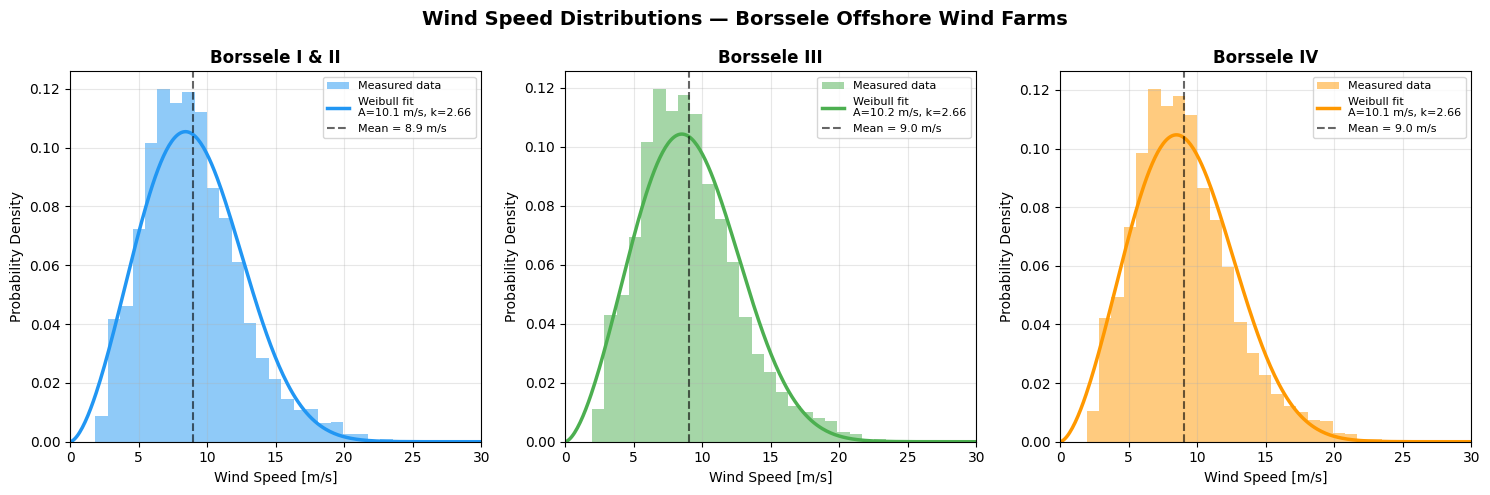

Plot saved as borssele_weibull_distributions.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Wind Speed Distributions — Borssele Offshore Wind Farms", fontsize=14, fontweight="bold")

colors = ["#2196F3", "#4CAF50", "#FF9800"]

for ax, wf, color in zip(axes, wind_farms, colors):
    ws = all_wind_data[wf["name"]]["wind_speed_ms"].values
    A, k = wf["weibull_A"], wf["weibull_k"]
    
    # Histogram of actual wind speeds
    ax.hist(ws, bins=30, density=True, alpha=0.5, color=color, label="Measured data")
    
    # Weibull curve
    ws_range = np.linspace(0, 30, 300)
    weibull_pdf = weibull_min.pdf(ws_range, c=k, scale=A)
    ax.plot(ws_range, weibull_pdf, color=color, linewidth=2.5, label=f"Weibull fit\nA={A:.1f} m/s, k={k:.2f}")
    
    ax.axvline(wf["mean_ws"], color="black", linestyle="--", alpha=0.6, label=f"Mean = {wf['mean_ws']:.1f} m/s")
    
    ax.set_title(wf["name"], fontsize=12, fontweight="bold")
    ax.set_xlabel("Wind Speed [m/s]")
    ax.set_ylabel("Probability Density")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 30)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("borssele_weibull_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as borssele_weibull_distributions.png")

---
## Step 6 — Define Turbine Power Curves

A **power curve** tells us: *"at this wind speed, the turbine produces this many megawatts"*.

- Below **cut-in speed** → turbine is off (not enough wind)
- Between **cut-in** and **rated speed** → power increases roughly with wind speed³
- Above **rated speed** → turbine is at full power
- Above **cut-out speed** → turbine shuts down to avoid storm damage

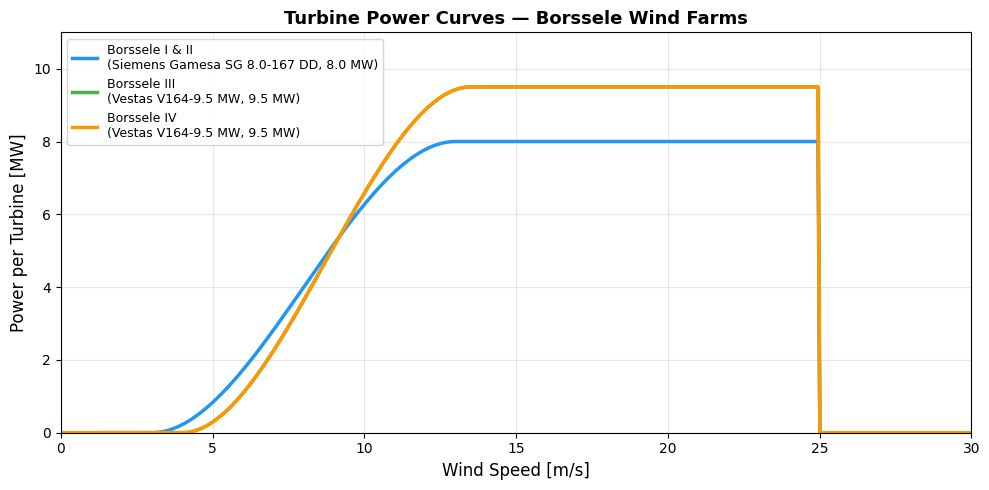

Plot saved as borssele_power_curves.png


In [21]:
def make_power_curve(rated_power_mw, cutin_ws, rated_ws, cutout_ws, n_points=500):
    """
    Create a simplified power curve for a wind turbine.
    
    The curve follows 3 regions:
      1. Below cut-in:  P = 0
      2. Cut-in to rated: P scales with wind speed (cubic-ish, capped at rated)
      3. Rated to cut-out: P = rated_power (full power)
      4. Above cut-out:  P = 0 (emergency shutdown)
    """
    ws_array = np.linspace(0, 30, n_points)
    power_array = np.zeros(n_points)
    
    for i, ws in enumerate(ws_array):
        if ws < cutin_ws or ws > cutout_ws:
            power_array[i] = 0.0
        elif ws >= rated_ws:
            power_array[i] = rated_power_mw  # Full rated power
        else:
            # Smooth S-curve between cut-in and rated using cubic interpolation
            # This approximates real turbine behaviour
            t = (ws - cutin_ws) / (rated_ws - cutin_ws)  # 0 → 1
            power_array[i] = rated_power_mw * (3*t**2 - 2*t**3)  # Smoothstep
    
    return ws_array, power_array


# Generate power curves for each farm
for wf in wind_farms:
    ws_curve, p_curve = make_power_curve(
        rated_power_mw=wf["rated_power_mw"],
        cutin_ws=wf["cutin_ws"],
        rated_ws=wf["rated_ws"],
        cutout_ws=wf["cutout_ws"],
    )
    wf["ws_curve"] = ws_curve
    wf["p_curve"] = p_curve

# Plot the power curves
fig, ax = plt.subplots(figsize=(10, 5))

colors = ["#2196F3", "#4CAF50", "#FF9800"]

for wf, color in zip(wind_farms, colors):
    ax.plot(wf["ws_curve"], wf["p_curve"], color=color, linewidth=2.5,
            label=f"{wf['name']}\n({wf['turbine_name']}, {wf['rated_power_mw']} MW)")

ax.set_xlabel("Wind Speed [m/s]", fontsize=12)
ax.set_ylabel("Power per Turbine [MW]", fontsize=12)
ax.set_title("Turbine Power Curves — Borssele Wind Farms", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 30)
ax.set_ylim(0, 11)

plt.tight_layout()
plt.savefig("borssele_power_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as borssele_power_curves.png")

---
## Step 7 — Calculate Annual Energy Production (AEP)

Now we combine the **Weibull distribution** (how often each wind speed occurs) with the **power curve** (how much power each wind speed produces) to get the **annual energy production**.

The formula is:

$$\text{AEP} = N_{\text{turbines}} \times 8760 \text{ hours} \times \int_0^{\infty} P(v) \cdot f(v) \, dv$$

where $P(v)$ is the power at wind speed $v$, and $f(v)$ is the Weibull probability density.

In [25]:
HOURS_PER_YEAR = 8760  # Hours in a year

def calculate_aep(wf):
    """
    Calculate Annual Energy Production for one wind farm.
    
    Method: Integrate (power curve × Weibull PDF) over all wind speeds.
    Result in GWh/year.
    """
    A = wf["weibull_A"]
    k = wf["weibull_k"]
    ws_curve = wf["ws_curve"]
    p_curve = wf["p_curve"]    # MW per turbine
    n_turbines = wf["n_turbines"]
    
    # Weibull probability density at each wind speed point
    weibull_pdf = weibull_min.pdf(ws_curve, c=k, scale=A)
    
    # Expected power per turbine = integral of (P(v) × f(v)) dv
    # We use numpy's trapezoid rule for numerical integration
    mean_power_per_turbine_mw = np.trapezoid(p_curve * weibull_pdf, ws_curve)
    
    # Gross AEP (no losses)
    aep_gross_gwh = mean_power_per_turbine_mw * n_turbines * HOURS_PER_YEAR / 1000

    # Loss factors (industry standard estimates for North Sea offshore)
    wake_loss        = 0.12   # 12% — turbines shadowing each other
    availability     = 0.05   # 5%  — maintenance downtime
    electrical_loss  = 0.03   # 3%  — cables and transformers
    total_loss = 1 - (1 - wake_loss) * (1 - availability) * (1 - electrical_loss)

    # Net AEP after losses
    aep_gwh = aep_gross_gwh * (1 - total_loss)

    # Capacity factors
    max_possible_gwh = wf["rated_power_mw"] * n_turbines * HOURS_PER_YEAR / 1000
    capacity_factor = aep_gwh / max_possible_gwh
    wf["aep_gross_gwh"] = aep_gross_gwh
    wf["total_loss_pct"] = total_loss * 100
    
    return aep_gwh, capacity_factor, mean_power_per_turbine_mw


# Calculate AEP for all farms
print("Calculating Annual Energy Production...\n")

total_aep_gross = 0
total_aep_net = 0
total_capacity = 0

for wf in wind_farms:
    aep, cf, mean_p = calculate_aep(wf)
    wf["aep_gwh"] = aep
    wf["capacity_factor"] = cf
    wf["mean_power_mw"] = mean_p
    
    farm_capacity = wf["n_turbines"] * wf["rated_power_mw"]
    total_aep_gross += wf["aep_gross_gwh"]
    total_aep_net += aep
    total_capacity += farm_capacity
    
    print(f"  {wf['name']}")
    print(f"    Total capacity:   {farm_capacity:.0f} MW")
    print(f"    Mean wind speed:  {wf['mean_ws']:.1f} m/s  (Weibull A={wf['weibull_A']:.1f}, k={wf['weibull_k']:.2f})")
    print(f"    Gross AEP:        {wf['aep_gross_gwh']:.1f} GWh/year")
    print(f"    Total losses:     {wf['total_loss_pct']:.1f}%  (wake 12% + availability 5% + electrical 3%)")
    print(f"    Net AEP:          {aep:.1f} GWh/year")
    print(f"    Capacity factor:  {cf*100:.1f}%  (net)")
    print()

print("─" * 50)
print(f"  TOTAL (all 3 farms):")
print(f"    Total capacity:  {total_capacity:.0f} MW")
print(f"    Gross AEP:       {total_aep_gross:.0f} GWh/year")
print(f"    Net AEP:         {total_aep_net:.0f} GWh/year  (after {wf['total_loss_pct']:.1f}% losses)")
print(f"    = {total_aep_net/1000:.2f} TWh/year")
print(f"  (Real reported Borssele AEP: ~6,000 GWh/year)")
print("─" * 50)

Calculating Annual Energy Production...

  Borssele I & II
    Total capacity:   752 MW
    Mean wind speed:  8.9 m/s  (Weibull A=10.1, k=2.66)
    Gross AEP:        3781.4 GWh/year
    Total losses:     18.9%  (wake 12% + availability 5% + electrical 3%)
    Net AEP:          3066.4 GWh/year
    Capacity factor:  46.5%  (net)

  Borssele III
    Total capacity:   732 MW
    Mean wind speed:  9.0 m/s  (Weibull A=10.2, k=2.66)
    Gross AEP:        3295.0 GWh/year
    Total losses:     18.9%  (wake 12% + availability 5% + electrical 3%)
    Net AEP:          2672.0 GWh/year
    Capacity factor:  41.7%  (net)

  Borssele IV
    Total capacity:   19 MW
    Mean wind speed:  9.0 m/s  (Weibull A=10.1, k=2.66)
    Gross AEP:        85.2 GWh/year
    Total losses:     18.9%  (wake 12% + availability 5% + electrical 3%)
    Net AEP:          69.1 GWh/year
    Capacity factor:  41.5%  (net)

──────────────────────────────────────────────────
  TOTAL (all 3 farms):
    Total capacity:  1502 MW
 

---
## Step 8 — Results Summary Plot

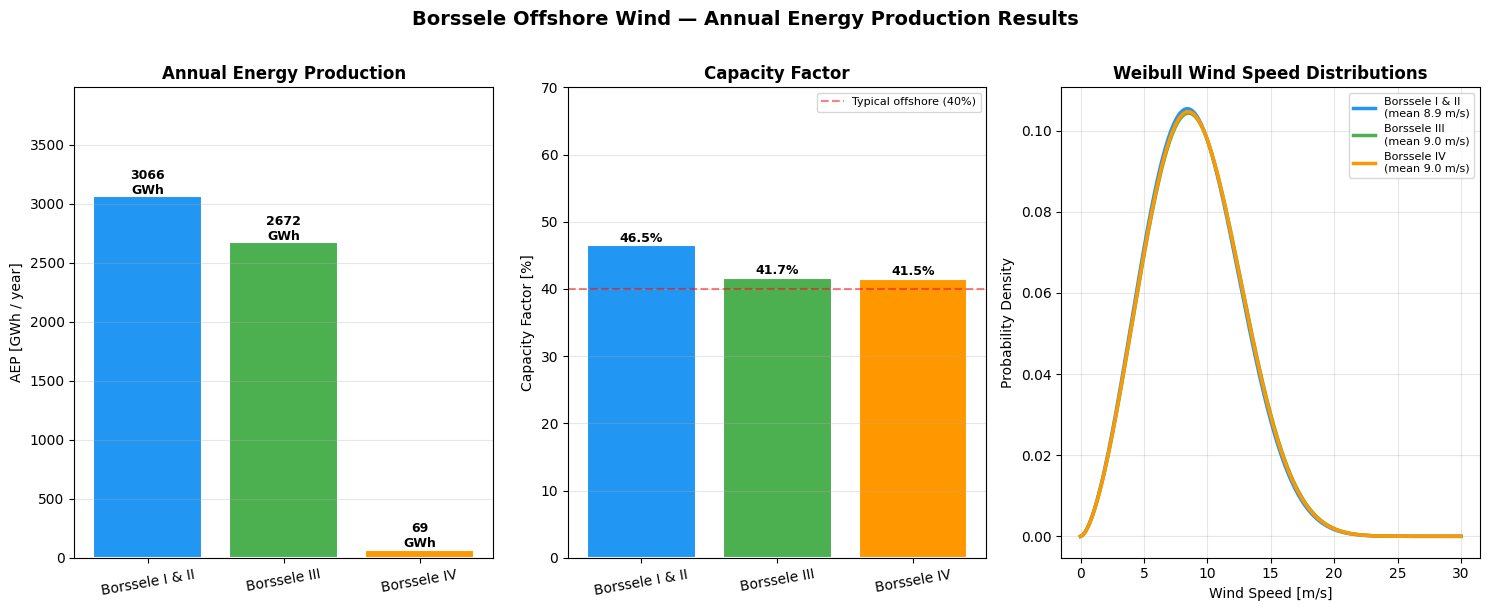

Plot saved as borssele_results_summary.png


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle("Borssele Offshore Wind — Annual Energy Production Results", 
             fontsize=14, fontweight="bold", y=1.01)

colors = ["#2196F3", "#4CAF50", "#FF9800"]
names = [wf["name"] for wf in wind_farms]

# ── Plot 1: AEP bar chart ──────────────────────────────────────────────
ax = axes[0]
aep_values = [wf["aep_gwh"] for wf in wind_farms]
bars = ax.bar(names, aep_values, color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, aep_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f"{val:.0f}\nGWh", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("AEP [GWh / year]")
ax.set_title("Annual Energy Production", fontweight="bold")
ax.set_ylim(0, max(aep_values) * 1.3)
ax.tick_params(axis='x', rotation=10)
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Capacity factor ────────────────────────────────────────────
ax = axes[1]
cf_values = [wf["capacity_factor"] * 100 for wf in wind_farms]
bars = ax.bar(names, cf_values, color=colors, edgecolor="white", linewidth=1.5)
for bar, val in zip(bars, cf_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.axhline(40, color="red", linestyle="--", alpha=0.5, label="Typical offshore (40%)")
ax.set_ylabel("Capacity Factor [%]")
ax.set_title("Capacity Factor", fontweight="bold")
ax.set_ylim(0, 70)
ax.legend(fontsize=8)
ax.tick_params(axis='x', rotation=10)
ax.grid(axis="y", alpha=0.3)

# ── Plot 3: Wind speed histogram (combined) ────────────────────────────
ax = axes[2]
ws_range = np.linspace(0, 30, 300)
for wf, color in zip(wind_farms, colors):
    A, k = wf["weibull_A"], wf["weibull_k"]
    pdf = weibull_min.pdf(ws_range, c=k, scale=A)
    ax.plot(ws_range, pdf, color=color, linewidth=2.5, label=f"{wf['name']}\n(mean {wf['mean_ws']:.1f} m/s)")
ax.set_xlabel("Wind Speed [m/s]")
ax.set_ylabel("Probability Density")
ax.set_title("Weibull Wind Speed Distributions", fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("borssele_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved as borssele_results_summary.png")

---
## Step 9 — Final Summary Table

In [ ]:
# Build a clean summary DataFrame
rows = []
for wf in wind_farms:
    rows.append({
        "Farm": wf["name"],
        "Turbine": wf["turbine_name"],
        "# Turbines": wf["n_turbines"],
        "Total Capacity (MW)": wf["n_turbines"] * wf["rated_power_mw"],
        "Mean Wind Speed (m/s)": round(wf["mean_ws"], 2),
        "Weibull A (m/s)": round(wf["weibull_A"], 2),
        "Weibull k": round(wf["weibull_k"], 3),
        "Gross AEP (GWh/yr)": round(wf["aep_gross_gwh"], 1),
        "Losses (%)": round(wf["total_loss_pct"], 1),
        "Net AEP (GWh/yr)": round(wf["aep_gwh"], 1),
        "Capacity Factor (%)": round(wf["capacity_factor"] * 100, 1),
    })

# Add totals row
rows.append({
    "Farm": "✅ TOTAL",
    "Turbine": "",
    "# Turbines": sum(wf["n_turbines"] for wf in wind_farms),
    "Total Capacity (MW)": sum(wf["n_turbines"] * wf["rated_power_mw"] for wf in wind_farms),
    "Mean Wind Speed (m/s)": "",
    "Weibull A (m/s)": "",
    "Weibull k": "",
    "Gross AEP (GWh/yr)": round(sum(wf["aep_gross_gwh"] for wf in wind_farms), 1),
    "Losses (%)": round(wind_farms[0]["total_loss_pct"], 1),
    "Net AEP (GWh/yr)": round(sum(wf["aep_gwh"] for wf in wind_farms), 1),
    "Capacity Factor (%)": "",
})

summary_df = pd.DataFrame(rows)
display(summary_df)

# Save to CSV
summary_df.to_csv("borssele_aep_results.csv", index=False)
print("\nResults saved to: borssele_aep_results.csv")

# Context
total_net_gwh = sum(wf["aep_gwh"] for wf in wind_farms)
total_gross_gwh = sum(wf["aep_gross_gwh"] for wf in wind_farms)
homes_powered = total_net_gwh * 1000 / 3.5
print(f"\n📊 Gross AEP:  {total_gross_gwh:.0f} GWh/year")
print(f"   Net AEP:    {total_net_gwh:.0f} GWh/year  (after wake + availability + electrical losses)")
print(f"   Real Borssele reported: ~6,000 GWh/year")
print(f"\n💡 Fun fact: {total_net_gwh:.0f} GWh is enough to power ~{homes_powered/1e6:.1f} million Dutch homes!")
print(f"   (assuming average use of 3,500 kWh/household/year)")

,Farm,Turbine,# Turbines,Rated Power (MW),Total Capacity (MW),Mean Wind Speed (m/s),Weibull A (m/s),Weibull k,AEP (GWh/yr),Capacity Factor (%)
0,Borssele I & II,Siemens Gamesa SG 8.0-167 DD,94,8.0,752.0,8.94,10.06,2.656,3066.4,46.5
1,Borssele III,Vestas V164-9.5 MW,77,9.5,731.5,9.04,10.17,2.658,2672.0,41.7
2,Borssele IV,Vestas V164-9.5 MW,2,9.5,19.0,9.01,10.14,2.659,69.1,41.5
3,✅ TOTAL,,173,,1502.5,,,,5807.4,



Results saved to: borssele_aep_results.csv

💡 Fun fact: 5807 GWh is enough to power ~1.7 million Dutch homes!
   (assuming average use of 3,500 kWh/household/year)


---
## Notes & Limitations

This is a **simplified model** designed to be transparent and educational. A few things to keep in mind:

**What this model does:**
- ✅ Uses real meteorological wind data (NASA MERRA-2 via Renewables.ninja)
- ✅ Fits a standard Weibull distribution per site
- ✅ Uses realistic turbine specifications (rated power, cut-in/out speeds)
- ✅ Computes AEP via Weibull–power curve integration

**What this model does NOT include:**
- ❌ **Wake losses** — turbines block wind for turbines behind them (~10–20% loss in dense farms)
- ❌ **Availability losses** — turbines are offline ~5% of the time for maintenance
- ❌ **Electrical losses** — cables and transformers lose ~2–3% of power
- ❌ **Wind direction effects** — the Weibull here is omni-directional (no wind rose per sector)
- ❌ **Detailed power curves** — we use a smoothed approximation, not manufacturer data

For a full engineering study, these losses would reduce the AEP estimate by roughly **15–25%**.

**Reference:** The real Borssele complex (I+II+III+IV) has a combined capacity of ~1,494 MW and is expected to produce approximately 6,000 GWh/year — so this model should give results in a broadly similar ballpark (before wake/availability deductions).